# 01_EDA - Análisis Exploratorio de Datos de Sensores Nucleares

**Objetivo**: Explorar las series temporales de los sensores de una central nuclear simulada (PCTRAN) para identificar patrones distintivos en 18 tipos de accidentes. Este análisis guiará la selección de sensores para la etapa de extracción de características y modelado.

**Contexto físico**: Los datos provienen de simulaciones de un reactor PWR (Water Pressurized Reactor). Los sensores incluyen variables críticas como temperatura, presión, flujos y niveles, que son esenciales para el diagnóstico de accidentes (LOCA, ATWS, SGBTR, etc.). La normativa de seguridad nuclear (NUREG-0800) establece la importancia de monitorizar estas variables para la detección temprana de eventos.

---

## 1. Configuración inicial

Importamos las librerías necesarias y configuramos el proyecto para poder utilizar los módulos personalizados de `src/`. También definimos las rutas de datos y salida de imágenes.

In [1]:
import sys
import os

# Añadir la raíz del proyecto al path para importar src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.utils import cargar_datos, graficar_series_temporales, crear_carpeta
from src.features import seleccionar_columnas, COLUMNAS_5, UNIDADES_5

# Rutas
DATA_PATH = "../data/processed/operation/"
OUTPUT_IMAGES = "../results/imagenes/EDA/"
crear_carpeta(OUTPUT_IMAGES)

## 2. Carga de datos

Cargamos los archivos CSV correspondientes a cada tipo de accidente. Cada carpeta contiene un archivo por nivel de severidad (ej. `1.csv`, `2.csv`, ...). Para este análisis exploratorio, cargamos el **primer archivo de cada carpeta** (severidad base) para tener una visión general de cada accidente.

In [2]:
df_list, accident_names = cargar_datos(DATA_PATH)
print(f"Hemos cargado {len(df_list)} datasets")

Hemos cargado 18 datasets


Seleccionamos las columnas de los 5 sensores elegidos inicialmente:

* `P` (Press RCS): Presión del Sistema de Refrigerante del Reactor (bar). Es la variable más directa para detectar pérdidas de inventario o sobrepresurización.
* `TAVG` (Temp RCS average): Temperatura promedio del Sistema de Refrigerante del Reactor (°C). Refleja el balance térmico del núcleo y la capacidad de extracción de calor.
* `LVPZ` (Level Pressurizer): Nivel del Presurizador (%). Indica el inventario de agua en el primario. Es clave para detectar pérdidas de refrigerante.
* `WBK` (Flow Total break entering RB): Flujo total de la rotura que entra en el edificio del reactor (t/h). Mide la tasa de fuga en caso de rotura en el primario.
* `LSGA` (Level SG A wide range): Nivel del Generador de Vapor A en rango amplio (m). Refleja el inventario de agua en el secundario y la transferencia de calor.

In [3]:
df_list_5 = seleccionar_columnas(df_list, COLUMNAS_5)
print(f"Seleccionadas {len(COLUMNAS_5)} columnas en {len(df_list_5)} dataframes")

Seleccionadas 6 columnas en 18 dataframes


## 3. Visualización de series temporales

Generamos un gráfico por accidente con la evolución de los 5 sensores. Cada sensor se representa con un estilo de línea y marcador diferente para facilitar la identificación (importante para evitar dependencia del color). Los gráficos se guardan en la carpeta `results/imagenes/EDA/` y se muestran en el notebook para su análisis.

Guardado: ../results/imagenes/EDA/01_EDA_ATWS_5_sensors.png


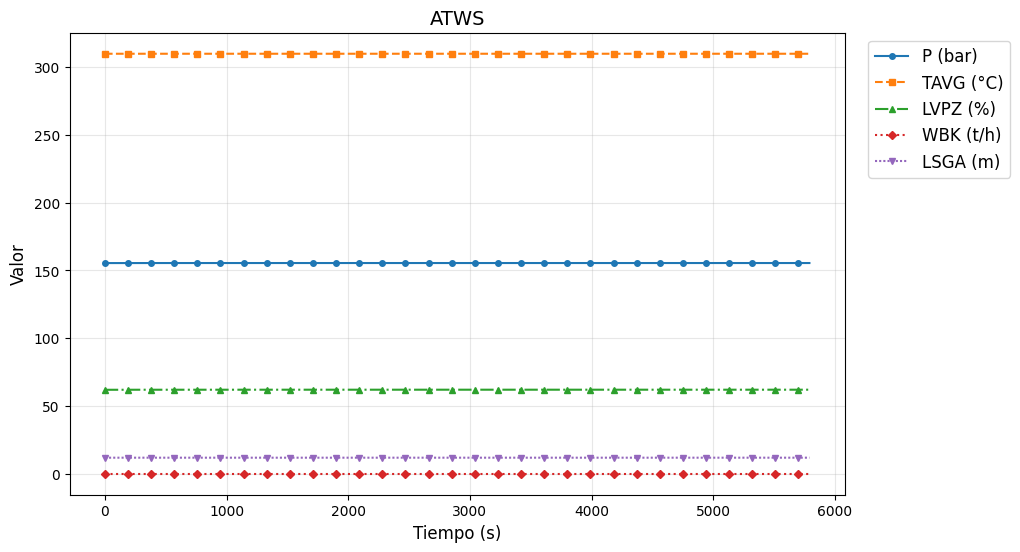

Guardado: ../results/imagenes/EDA/01_EDA_FLB_5_sensors.png


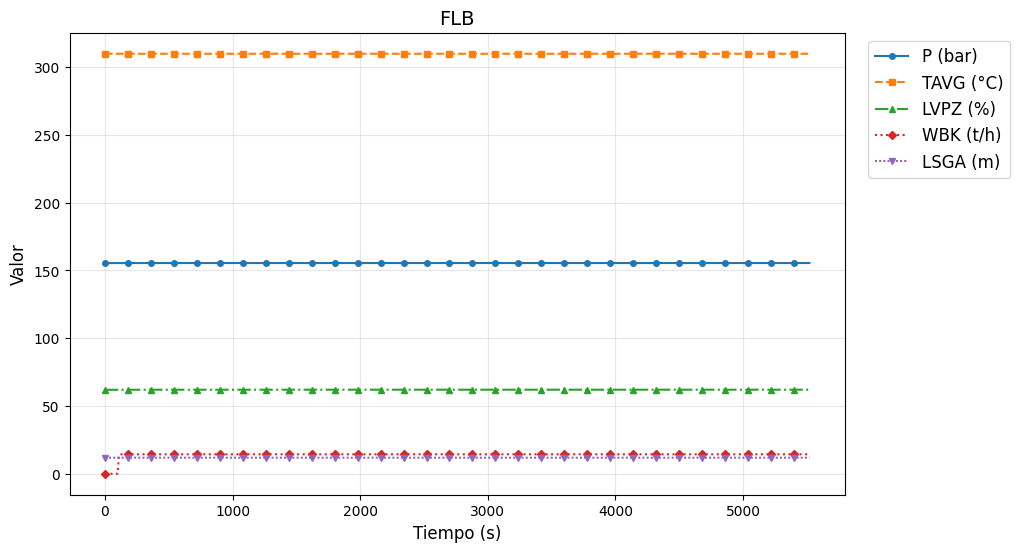

Guardado: ../results/imagenes/EDA/01_EDA_LACP_5_sensors.png


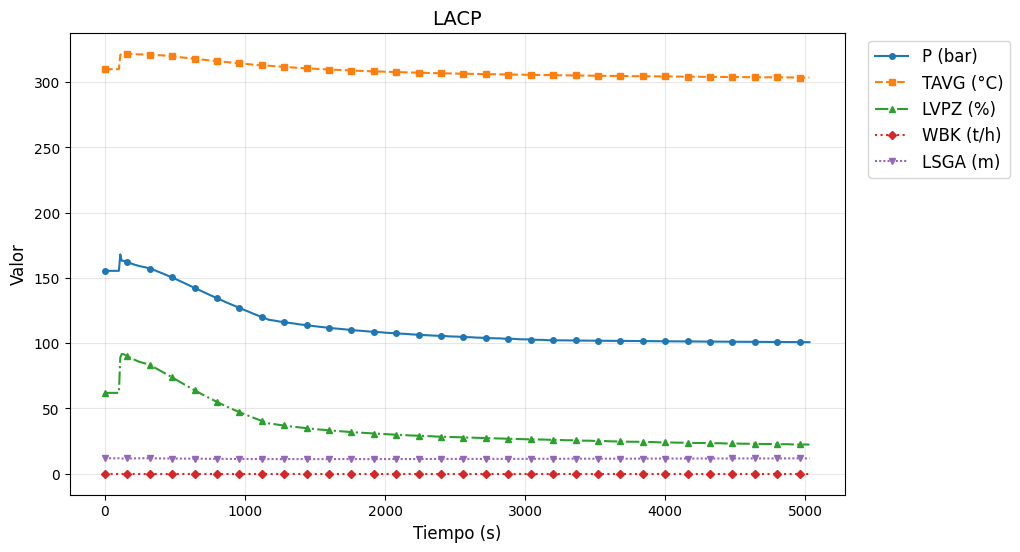

Guardado: ../results/imagenes/EDA/01_EDA_LLB_5_sensors.png


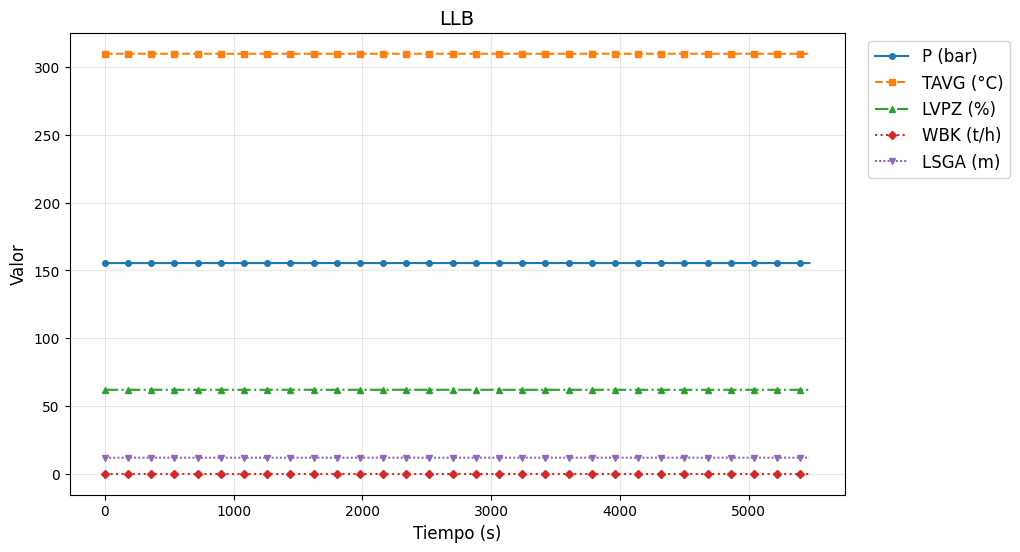

Guardado: ../results/imagenes/EDA/01_EDA_LOCA_5_sensors.png


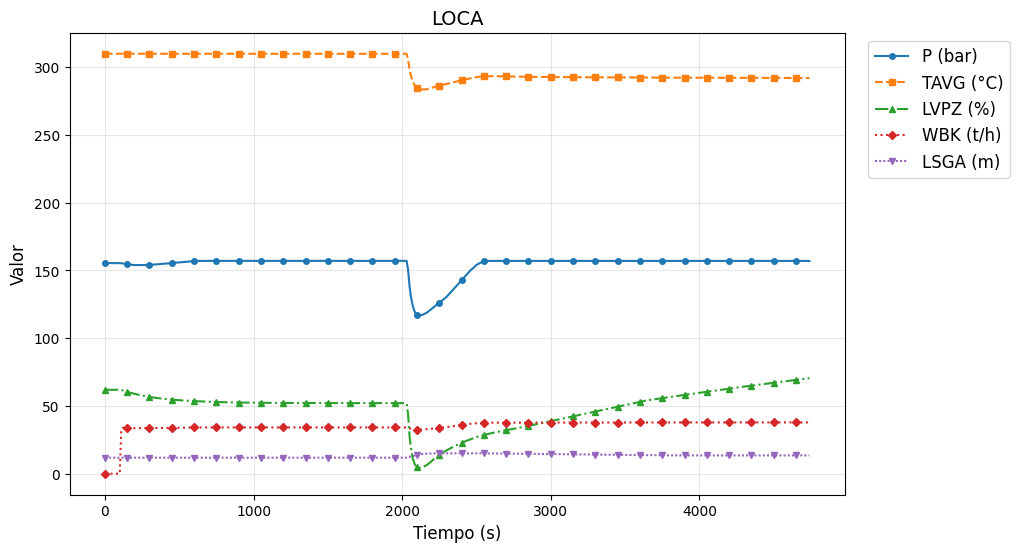

Guardado: ../results/imagenes/EDA/01_EDA_LOCAC_5_sensors.png


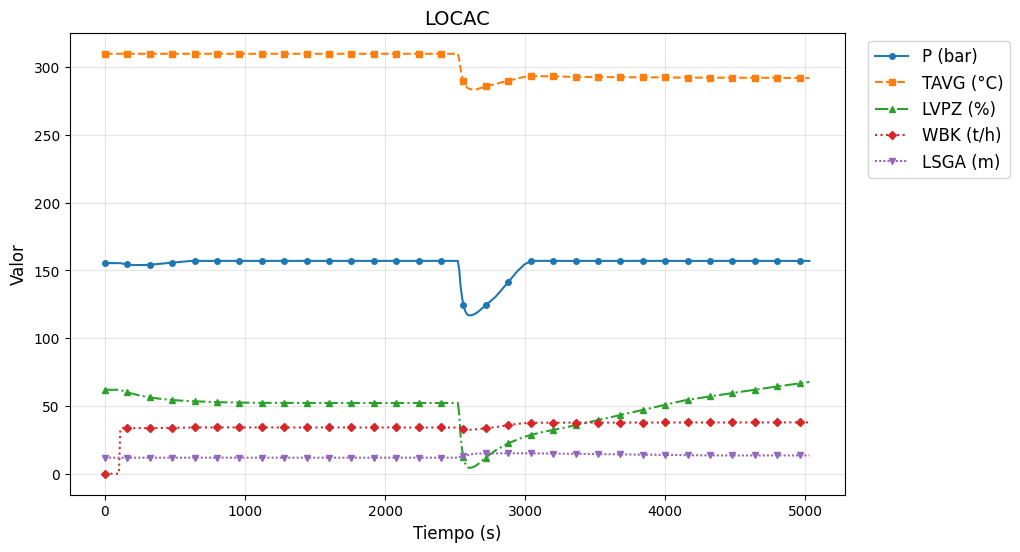

Guardado: ../results/imagenes/EDA/01_EDA_LOF_5_sensors.png


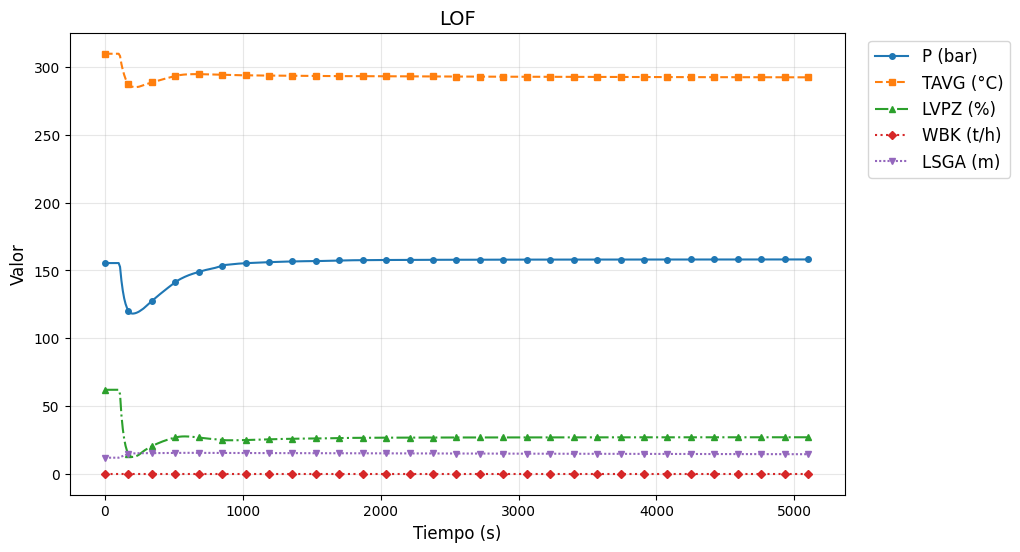

Guardado: ../results/imagenes/EDA/01_EDA_LR_5_sensors.png


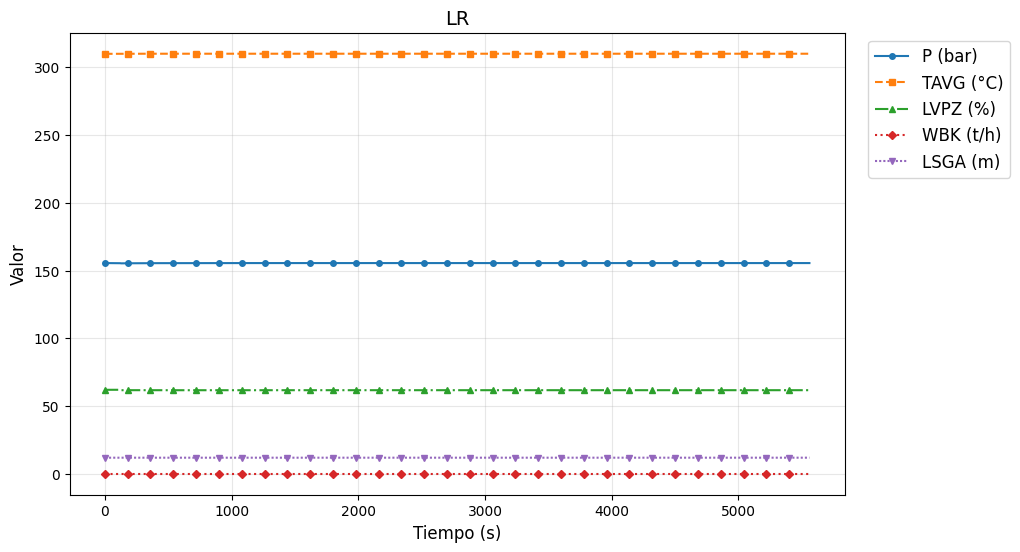

Guardado: ../results/imagenes/EDA/01_EDA_MD_5_sensors.png


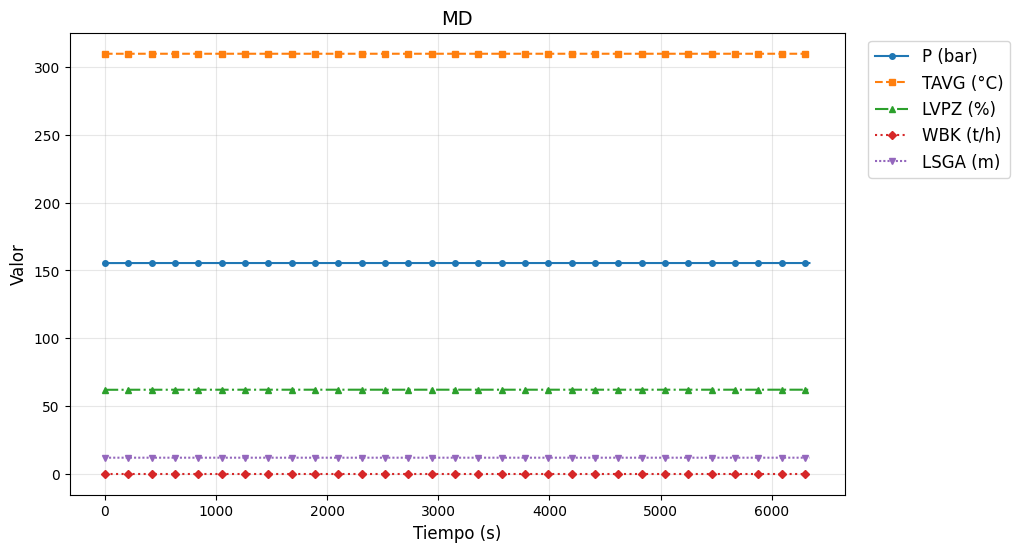

Guardado: ../results/imagenes/EDA/01_EDA_Normal_5_sensors.png


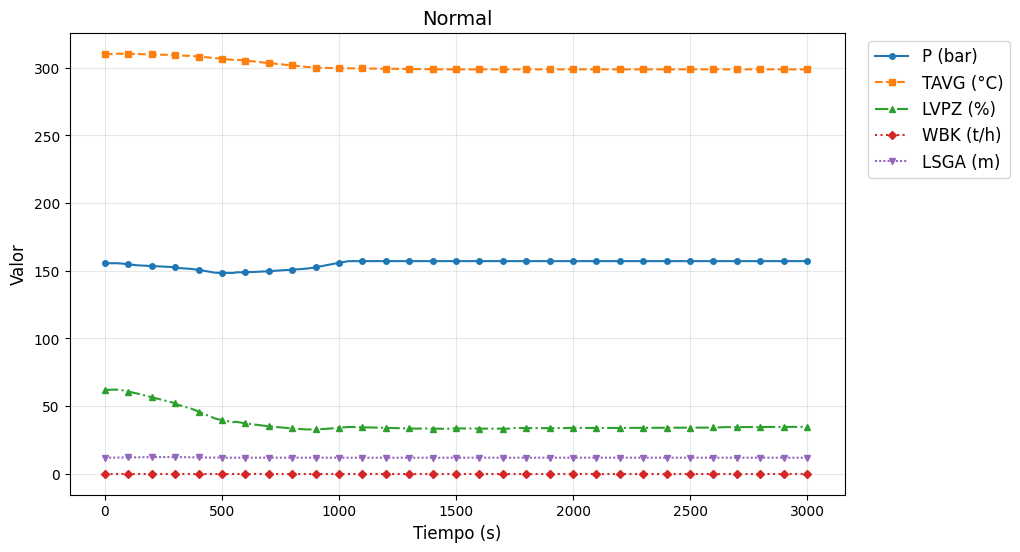

Guardado: ../results/imagenes/EDA/01_EDA_RI_5_sensors.png


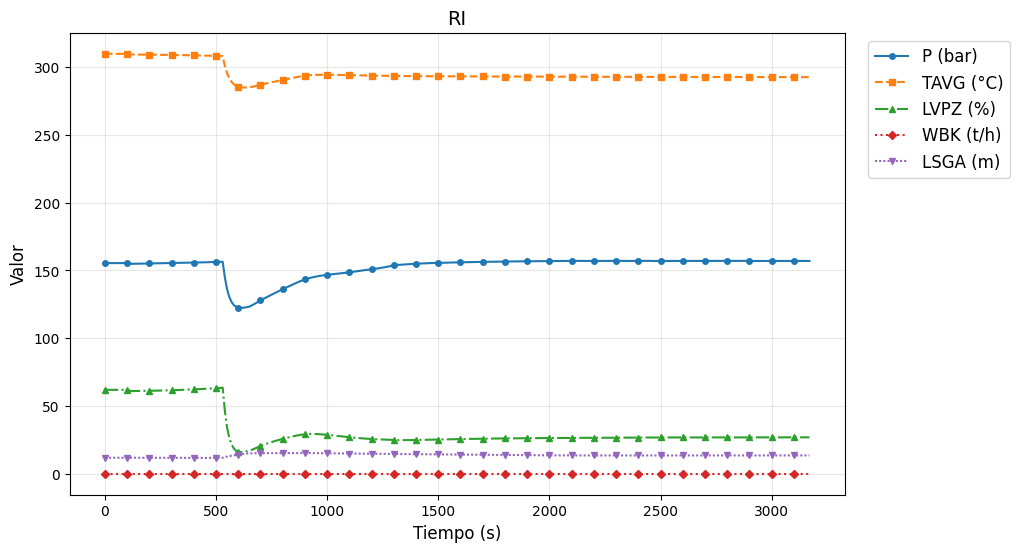

Guardado: ../results/imagenes/EDA/01_EDA_RW_5_sensors.png


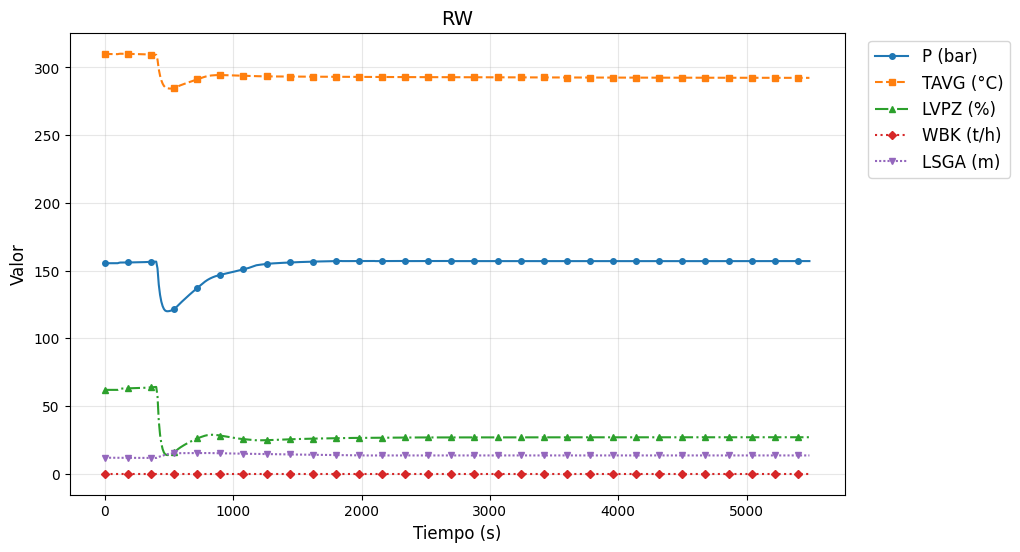

Guardado: ../results/imagenes/EDA/01_EDA_SGATR_5_sensors.png


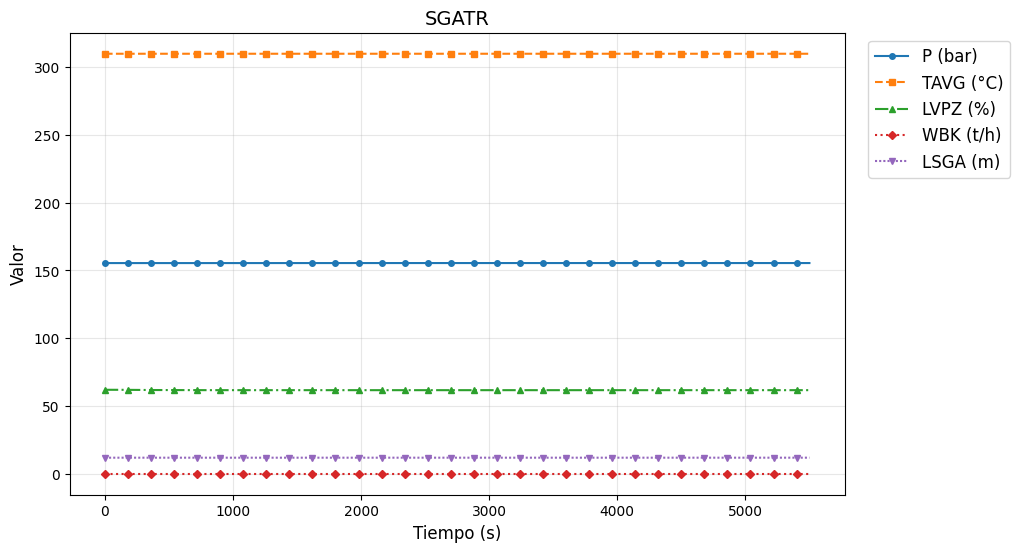

Guardado: ../results/imagenes/EDA/01_EDA_SGBTR_5_sensors.png


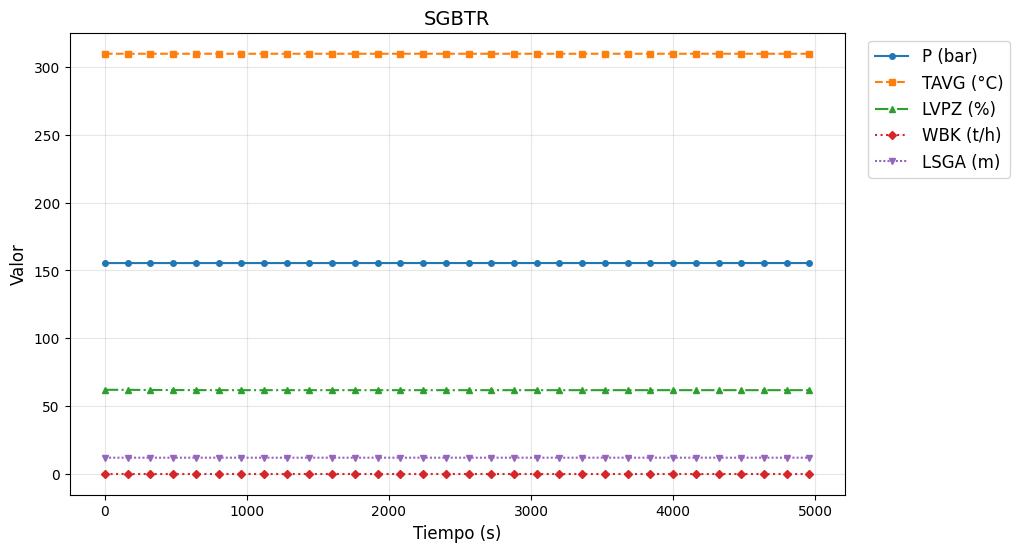

Guardado: ../results/imagenes/EDA/01_EDA_SLBIC_5_sensors.png


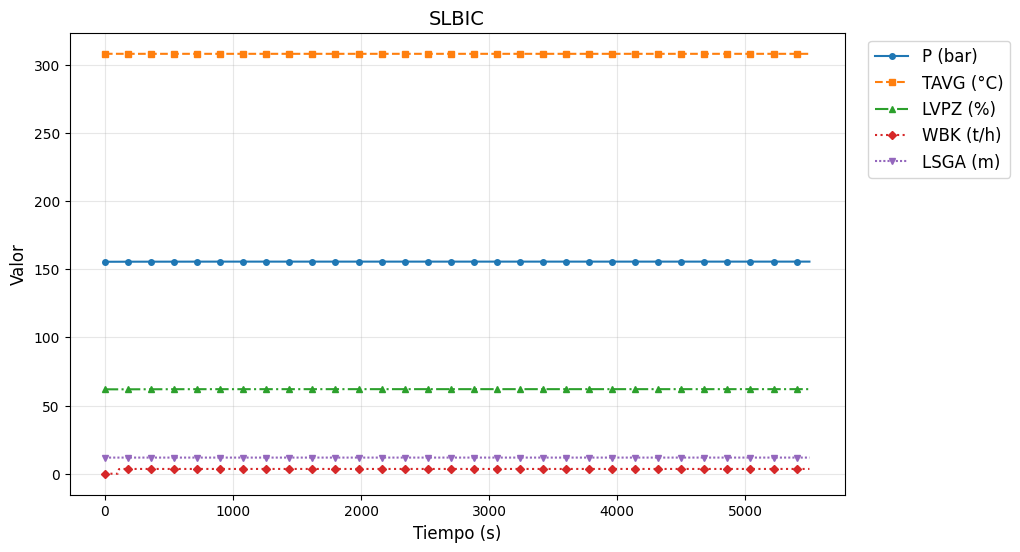

Guardado: ../results/imagenes/EDA/01_EDA_SLBOC_5_sensors.png


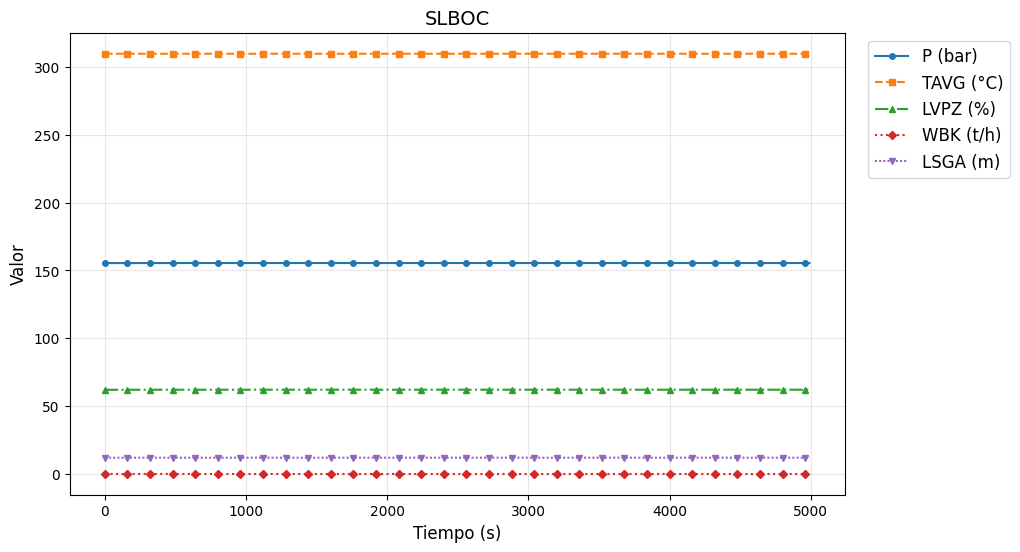

Guardado: ../results/imagenes/EDA/01_EDA_SP_5_sensors.png


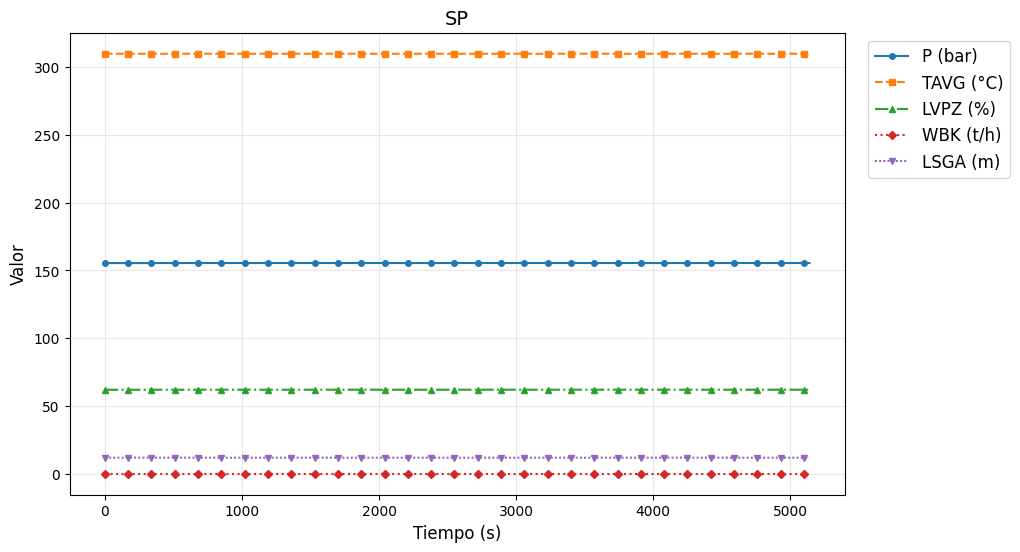

Guardado: ../results/imagenes/EDA/01_EDA_TT_5_sensors.png


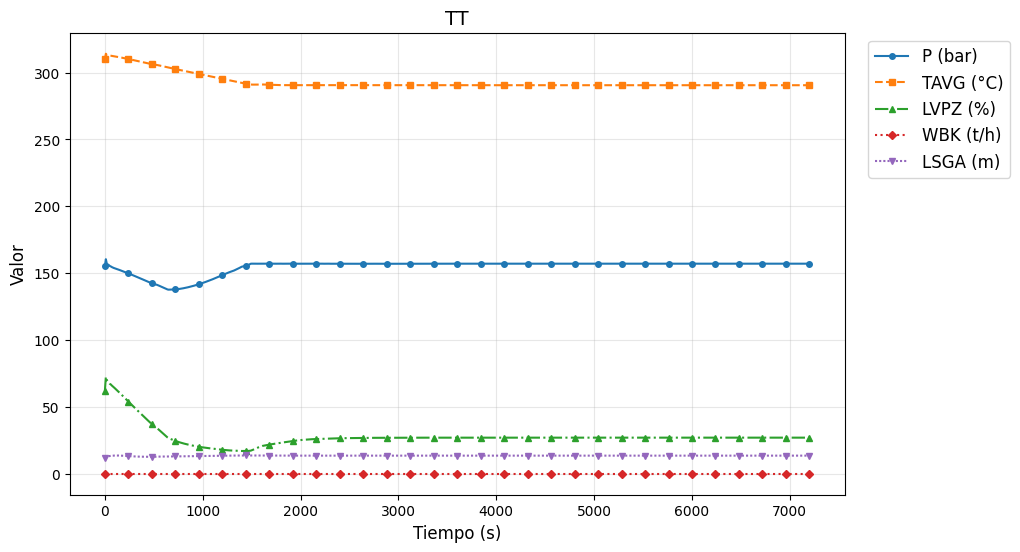

¡Proceso completado!


In [4]:
estilos = [
    {'linestyle': '-',  'marker': 'o'},
    {'linestyle': '--', 'marker': 's'},
    {'linestyle': '-.', 'marker': '^'},
    {'linestyle': ':',  'marker': 'D'},
    {'linestyle': (0, (1, 1)), 'marker': 'v'}
]

graficar_series_temporales(
    df_list_5,
    accident_names,
    sensores=COLUMNAS_5[1:],
    unidades=UNIDADES_5[1:],
    estilos=estilos,
    carpeta_salida=OUTPUT_IMAGES,
    prefijo="01_EDA",
    show=True  # Mostrar en el notebook para comentar
)
print("¡Proceso completado!")

## 4. Interpretación de los gráficos

Al observar los gráficos generados, se aprecian comportamientos muy diferentes según el tipo de accidente. Destacamos dos casos con variaciones significativas que son fáciles de identificar:

### 4.1. LOF (Loss of Flow - Locked Rotor)

Este accidente simula el bloqueo del rotor de **una** de las bombas principales (ej. lazo A). La otra bomba (lazo B) sigue funcionando. El reactor se dispara (scram) y la potencia cae a niveles residuales.

- **TAVG (Temp RCS average)**: Desciende aproximadamente **20 unidades (°C)** alrededor del segundo **100**. El lazo A se queda sin circulación: el agua que hay en su generador de vapor se enfría al ceder calor al secundario, pero no vuelve al núcleo a recalentarse. El lazo B extrae el calor residual del núcleo, pero al ser el reactor ya parado, el calor generado es insuficiente para compensar el enfriamiento del lazo A. Por tanto, la temperatura media de todo el sistema baja.

- **P (Press RCS)**: Cae unas **40 unidades (bar)**. La pérdida del impulso de la bomba A reduce la presión total, y el enfriamiento global del primario provoca contracción del agua, contribuyendo a la caída.

- **LVPZ (Level Pressurizer)**: Desciende unas **50 unidades (%)**. Al enfriarse el agua del primario, se contrae (ocupa menos volumen). El presurizador cede agua al primario para compensar esta contracción, lo que reduce su nivel.

**Nota**: Estos cambios se deben exclusivamente a fenómenos térmicos (enfriamiento y contracción) y a la pérdida de impulso de una bomba.

### 4.2. LACP (Loss of AC Power)

Este accidente simula la pérdida total de alimentación eléctrica. **Todas las bombas principales se paran**. No hay circulación forzada en ningún lazo. El reactor se dispara, pero el calor residual sigue generándose en el núcleo.

- **TAVG**: Sube inicialmente unas **10 unidades (°C)** y luego desciende lentamente unas **20 unidades (°C)**. Al pararse todas las bombas, el agua del núcleo deja de circular hacia los generadores de vapor. El calor residual se acumula en el agua estancada del núcleo, provocando un calentamiento inicial. Cuando los sistemas de emergencia (bombas auxiliares, turbinas de vapor) entran en funcionamiento, se restablece cierta circulación y la temperatura comienza a descender.

- **P**: Sube unas **10 unidades (bar)** al inicio (por la expansión del agua caliente estancada en el núcleo) y luego cae lentamente unas **60 unidades (bar)** a medida que la refrigeración de emergencia enfría el sistema y el agua se contrae.

- **LVPZ**: Sube unas **30 unidades (%)** al inicio (por la expansión térmica del refrigerante al calentarse en el núcleo) y luego cae lentamente unas **50 unidades (%)** a medida que el sistema se enfría y el volumen de agua se reduce.

**Nota**: Las variaciones de nivel del presurizador son debidas a la expansión y contracción térmica del agua, no a fugas. La subida inicial refleja el calentamiento del agua estancada en el núcleo; la bajada posterior, el enfriamiento al activarse los sistemas de emergencia.

### 4.3. Conclusión de la exploración

- Los accidentes LOF y LACP muestran **patrones claros y diferenciados** en los sensores de presión, temperatura y nivel del presionador.
- Accidentes (como ATWS o SGBTR) apenas afectan a estos sensores, lo que indica que **el conjunto de 5 sensores es insuficiente para cubrir todos los tipos de accidentes**. Será necesario ampliar el conjunto.
- Además, la evolución temporal de los picos es clave: en LOF los cambios ocurren de forma rápida, mientras que en LACP hay una fase de expansión seguida de una caída lenta. Esto sugiere que la **dinámica temporal** (no solo los valores absolutos) contiene información importante para el diagnóstico.

En el siguiente notebook (`NPPAD_02_Feature_Engineering`) ampliaremos el número de sensores a 12 para cubrir también las áreas del secundario, neutrónica y contención. Extraeremos estadísticas (media, desviación, pendiente, tiempos de pico, etc.) que capturen tanto los valores absolutos como la dinámica temporal de cada sensor.